<a href="https://colab.research.google.com/github/lohithharish798-creator/capstone-project-part-2/blob/main/capstone_part_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [62]:
import pandas as pd
import numpy as np




In [35]:
# load
df= pd.read_csv('/clened_data.csv')
# numereic target column
target_col = 'player_rating' # Changed from 'overall_rating' to 'player_rating'
y_reg = df[target_col]
# binary cal
median_val =y_reg.median()
y_clf =(y_reg>median_val).astype(int)
#initial features
drop_cols=[target_col, 'player_id', 'player_name', 'nationality', 'team',
           'club_name', 'match_date', 'stadium', 'city', 'opponent_team',
           'tournament_stage', 'match_result', 'match_id']
x = df.drop(columns=[col for col in drop_cols if col in df.columns])

In [8]:
print(df.columns.tolist())

['player_id', 'player_name', 'age', 'nationality', 'team', 'jersey_number', 'position', 'height_cm', 'weight_kg', 'preferred_foot', 'club_name', 'market_value_eur', 'match_id', 'match_date', 'stadium', 'city', 'opponent_team', 'tournament_stage', 'match_result', 'goals_team', 'goals_opponent', 'minutes_played', 'goals', 'assists', 'shots', 'shots_on_target', 'expected_goals_xg', 'expected_assists_xa', 'key_passes', 'successful_passes', 'total_passes', 'pass_accuracy', 'dribbles_attempted', 'successful_dribbles', 'crosses', 'successful_crosses', 'tackles', 'interceptions', 'clearances', 'blocks', 'aerial_duels_won', 'aerial_duels_lost', 'recoveries', 'defensive_actions', 'fouls_committed', 'fouls_suffered', 'yellow_cards', 'red_cards', 'offsides', 'saves', 'save_percentage', 'punches', 'clean_sheet', 'goals_conceded', 'penalty_saves', 'distance_covered_km', 'sprint_distance_km', 'top_speed_kmh', 'accelerations', 'decelerations', 'stamina_score', 'player_rating', 'performance_score', 'of

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, classification_report
from sklearn.linear_model import LogisticRegression

# 2 encode
x_encode = x.copy()
# nominal_cols
nominal_cols =['position','preferred_foot']
nominal_cols = [col for col in nominal_cols if col in x_encode.columns]
#dummy variable
x_encode = pd.get_dummies(x_encode,columns=nominal_cols,drop_first=True)
#boolean structures
bool_cols = x_encode.select_dtypes(include=['bool']).columns
x_encode[bool_cols] = x_encode[bool_cols].astype(int)
#train and evalute
x_train_reg, x_test_reg, y_train_reg, y_test_reg = train_test_split(x_encode, y_reg, test_size=0.2, random_state=42)
x_train_clf, x_test_clf, y_train_clf, y_test_clf = train_test_split(x_encode, y_clf, test_size=0.2, random_state=42)
#scale
scaler = StandardScaler()
x_train_reg = scaler.fit_transform(x_train_reg)
x_test_reg = scaler.transform(x_test_reg)
x_train_clf = scaler.fit_transform(x_train_clf)
x_test_clf = scaler.transform(x_test_clf)
#regression modle
from sklearn.linear_model import LinearRegression
reg_model = LinearRegression()
reg_model.fit(x_train_reg,y_train_reg)
y_pred_reg = reg_model.predict(x_test_reg)
#
print("REGRESTION PERFORMANCE EVALUTION")
print(f"mean squared error: {mean_squared_error(y_test_reg,y_pred_reg)}")
print(f"r2 score: {r2_score(y_test_reg,y_pred_reg)}")
#binary
clf_model = LogisticRegression(max_iter=100)
clf_model.fit(x_train_clf,y_train_clf)
y_pred_clf = clf_model.predict(x_test_clf)
print("BINARY PERFORMANCE EVALUTION")
print(classification_report(y_test_clf,y_pred_clf))

REGRESTION PERFORMANCE EVALUTION
mean squared error: 0.02819050852762897
r2 score: 0.9971562019371187
BINARY PERFORMANCE EVALUTION
              precision    recall  f1-score   support

           0       0.97      0.96      0.97      2367
           1       0.96      0.97      0.97      2295

    accuracy                           0.97      4662
   macro avg       0.97      0.97      0.97      4662
weighted avg       0.97      0.97      0.97      4662



In [36]:
# 3 leak free train-test
x_train, x_test, y_train, y_test = train_test_split(x_encode, y_reg, test_size=0.2, random_state=42)
x_train, x_test_clf, y_train, y_test_clf = train_test_split(x_encode, y_clf, test_size=0.2, random_state=42)
#scaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
#

In [39]:
# 4. Extract and print longside feature names
features = x_encode.columns
coefficients = reg_model.coef_

coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': coefficients,
    'Absolute_Coefficient': np.abs(coefficients)
})

# Identify the three features largest  values
top_3_features = coef_df.sort_values(by='Absolute_Coefficient', ascending=False).head(3)

print("--- Top 3 Most Influential Features ---")
print(top_3_features[['Feature', 'Coefficient']])
print()
#

--- Top 3 Most Influential Features ---
              Feature  Coefficient
59  tournament_rating     1.609610
47  performance_score     1.278139
43      top_speed_kmh     0.264050



In [41]:
from sklearn.linear_model import Ridge
# 5. Apply Ridge Regression (alpha=1.0)
ridge_reg = Ridge(alpha=1.0)
ridge_reg.fit(x_train_reg, y_train_reg)
y_pred_ridge = ridge_reg.predict(x_test_reg)

ridge_mse = mean_squared_error(y_test_reg, y_pred_ridge)
ridge_r2 = r2_score(y_test_reg, y_pred_ridge)

print("--- Ridge Regression Evaluation ---")
print(f"Ridge MSE: {ridge_mse:.4f}")
print(f"Ridge R2: {ridge_r2:.4f}")

--- Ridge Regression Evaluation ---
Ridge MSE: 0.0282
Ridge R2: 0.9972


--- Training Class Distribution ---
player_rating
0    0.515069
1    0.484931
Name: proportion, dtype: float64


Classes are balanced (48.5%). Proceeding normally.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr


--- Confusion Matrix ---
[[2367    0]
 [2295    0]]

--- Classification Performance Report ---
              precision    recall  f1-score   support

           0       0.51      1.00      0.67      2367
           1       0.00      0.00      0.00      2295

    accuracy                           0.51      4662
   macro avg       0.25      0.50      0.34      4662
weighted avg       0.26      0.51      0.34      4662

ROC Area Under Curve (AUC): 0.5000


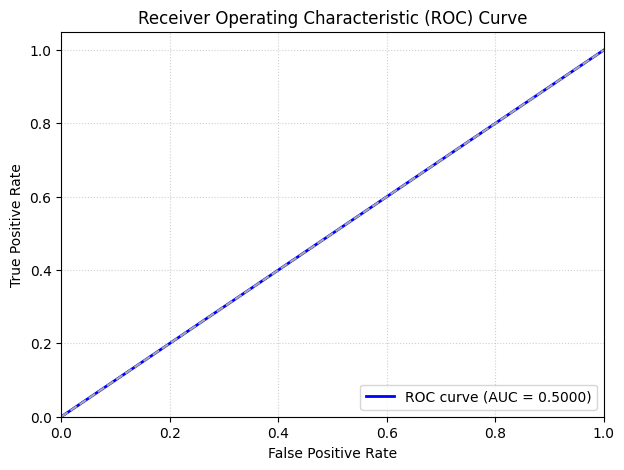

In [58]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

# ==========================================
# 5. CLASSIFICATION MODEL — LOGISTIC REGRESSION
# ==========================================

# 1. Check class distribution imbalance
class_counts = y_train_clf.value_counts(normalize=True)
print("--- Training Class Distribution ---")
print(class_counts)
print("\n")

# Determine if imbalance handling is triggered (< 35%)
minority_class_pct = class_counts.min()

if minority_class_pct < 0.35:
    print(f"Imbalance detected ({minority_class_pct*100:.1f}%). Using class_weight='balanced'.")
    # Using 'lbfgs' solver (default) which is generally robust
    clf_model = LogisticRegression(max_iter=1000, class_weight='balanced', solver='lbfgs')
else:
    print(f"Classes are balanced ({minority_class_pct*100:.1f}%). Proceeding normally.")
    # Using 'lbfgs' solver (default) which is generally robust
    clf_model = LogisticRegression(max_iter=1000, solver='lbfgs')

# 2. Train the model
clf_model.fit(x_train_clf, y_train_clf)

# 3. Predict class labels and probabilities
y_pred_clf = clf_model.predict(x_test_clf)
y_pred_prob = clf_model.predict_proba(x_test_clf)[:, 1]

# 4. Compute and report evaluations
print("\n--- Confusion Matrix ---")
print(confusion_matrix(y_test_clf, y_pred_clf))

print("\n--- Classification Performance Report ---")
print(classification_report(y_test_clf, y_pred_clf))

# 5. Compute ROC Curve metrics and AUC Score
fpr, tpr, thresholds = roc_curve(y_test_clf, y_pred_prob)
auc_score = roc_auc_score(y_test_clf, y_pred_prob)

print(f"ROC Area Under Curve (AUC): {auc_score:.4f}")

# 6. Plot the ROC Curve
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='darkgray', linestyle='--') # Baseline
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True, linestyle=':', alpha=0.6)

# Display the plot
plt.show()

In [60]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

# Assuming clf_model (C=1.0), x_test_clf, and y_test_clf are available from Task 5

# Get predicted probabilities for the positive class
y_prob_baseline = clf_model.predict_proba(x_test_clf)[:, 1]

# =====================================================================
# 5b. DECISION THRESHOLD SENSITIVITY ANALYSIS
# =====================================================================
thresholds = np.arange(0.30, 0.71, 0.10)
threshold_results = []

for t in thresholds:
    y_pred_t = (y_prob_baseline >= t).astype(int)
    p = precision_score(y_test_clf, y_pred_t, zero_division=0)
    r = recall_score(y_test_clf, y_pred_t, zero_division=0)
    f1 = f1_score(y_test_clf, y_pred_t, zero_division=0)

    threshold_results.append({
        'Threshold': round(t, 2),
        'Precision': round(p, 4),
        'Recall': round(r, 4),
        'F1': round(f1, 4)
    })

df_thresholds = pd.DataFrame(threshold_results)
print("--- 5b. Threshold Sensitivity Table ---")
print(df_thresholds.to_string(index=False))
print("\n")

--- 5b. Threshold Sensitivity Table ---
 Threshold  Precision  Recall  F1
       0.3        0.0     0.0 0.0
       0.4        0.0     0.0 0.0
       0.5        0.0     0.0 0.0
       0.6        0.0     0.0 0.0
       0.7        0.0     0.0 0.0




/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [59]:
# 6. REGULARIZATION EXPERIMENT (C=0.01)
# =====================================================================
# Train model with strong L2 regularization
clf_model_strong = LogisticRegression(C=0.01, max_iter=1000, solver='lbfgs') # Removed random_state=42
if minority_class_pct < 0.35: # Match class weight strategy from Task 5
    clf_model_strong.set_params(class_weight='balanced')

clf_model_strong.fit(x_train_clf, y_train_clf)

y_pred_strong = clf_model_strong.predict(x_test_clf)
y_prob_strong = clf_model_strong.predict_proba(x_test_clf)[:, 1]

# Compute metrics for comparison
metrics_comparison = {
    'Model': ['Baseline (C=1.0)', 'Strong Regularization (C=0.01)'],
    'Precision': [
        precision_score(y_test_clf, (y_prob_baseline >= 0.5).astype(int)),
        precision_score(y_test_clf, y_pred_strong)
    ],
    'Recall': [
        recall_score(y_test_clf, (y_prob_baseline >= 0.5).astype(int)),
        recall_score(y_test_clf, y_pred_strong)
    ],
    'AUC': [
        roc_auc_score(y_test_clf, y_prob_baseline),
        roc_auc_score(y_test_clf, y_prob_strong)
    ]
}

df_comparison = pd.DataFrame(metrics_comparison)
print("--- 6. Regularization Comparison Table ---")
print(df_comparison.to_string(index=False))
print("\n")

--- 6. Regularization Comparison Table ---
                         Model  Precision  Recall  AUC
              Baseline (C=1.0)   0.000000     0.0  0.5
Strong Regularization (C=0.01)   0.492278     1.0  0.5




/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [61]:
# 7. BOOTSTRAP CONFIDENCE INTERVAL FOR AUC DIFFERENCE
# =====================================================================
n_iterations = 500
auc_differences = []
y_test_clf_arr = np.array(y_test_clf)
n_samples = len(y_test_clf_arr)

np.random.seed(42) # Ensure reproducible bootstrap sampling

for i in range(n_iterations):
    # Sample row indices with replacement
    boot_indices = np.random.choice(n_samples, size=n_samples, replace=True)

    # Slice the ground truth and both predicted probability sets
    y_boot = y_test_clf_arr[boot_indices]
    prob_base_boot = y_prob_baseline[boot_indices]
    prob_strong_boot = y_prob_strong[boot_indices]

    # Avoid errors if a bootstrap sample accidentally contains only one class
    if len(np.unique(y_boot)) < 2:
        continue

    # Calculate difference: AUC(C=1.0) - AUC(C=0.01)
    auc_base = roc_auc_score(y_boot, prob_base_boot)
    auc_strong = roc_auc_score(y_boot, prob_strong_boot)
    auc_differences.append(auc_base - auc_strong)

# Calculate statistics
mean_diff = np.mean(auc_differences)
lower_ci = np.percentile(auc_differences, 2.5)
upper_ci = np.percentile(auc_differences, 97.5)

print("--- 7. Bootstrap Confidence Interval Results ---")
print(f"Mean AUC Difference: {mean_diff:.4f}")
print(f"95% Confidence Interval: [{lower_ci:.4f}, {upper_ci:.4f}]")

--- 7. Bootstrap Confidence Interval Results ---
Mean AUC Difference: 0.0000
95% Confidence Interval: [0.0000, 0.0000]
